<a target="_blank" href="https://colab.research.google.com/github/cesarschoollectures/am-labs/blob/main/assignments/E01_Decision_Tree.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Aprendizado de Máquina

# Questão 1

Utilize o dataset Iris disponível no scikit-learn.
Divida os dados em treino e teste utilizando divisão estratificada.

**Solução**:

In [19]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import pandas as pd

iris = load_iris(as_frame=True)

df = iris.frame

In [20]:
X = df.drop(columns="target")
y = df["target"]

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Treino: {X_treino.shape[0]} amostras")
print(f"Teste:  {X_teste.shape[0]} amostras")
print(f"\nDistribuição das classes no treino:\n{y_treino.value_counts().sort_index()}")
print(f"\nDistribuição das classes no teste:\n{y_teste.value_counts().sort_index()}")


Treino: 120 amostras
Teste:  30 amostras

Distribuição das classes no treino:
target
0    40
1    40
2    40
Name: count, dtype: int64

Distribuição das classes no teste:
target
0    10
1    10
2    10
Name: count, dtype: int64


# Questão 2

Treine um modelo utilizando `DecisionTreeClassifier`.

Depois calcule:

- acurácia no treino
- acurácia no teste

**Solução**:

In [21]:
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_treino, y_treino)

acc_treino = accuracy_score(y_treino, clf.predict(X_treino))
acc_teste = accuracy_score(y_teste, clf.predict(X_teste))

print(f"Acurácia no treino: {acc_treino:.4f}")
print(f"Acurácia no teste:  {acc_teste:.4f}")


Acurácia no treino: 1.0000
Acurácia no teste:  0.9333


# Questão 3

Utilize `plot_tree()` para visualizar a árvore treinada.

Responda:

1. Qual atributo aparece na raiz?
2. Qual é a profundidade da árvore?

**Solução**:

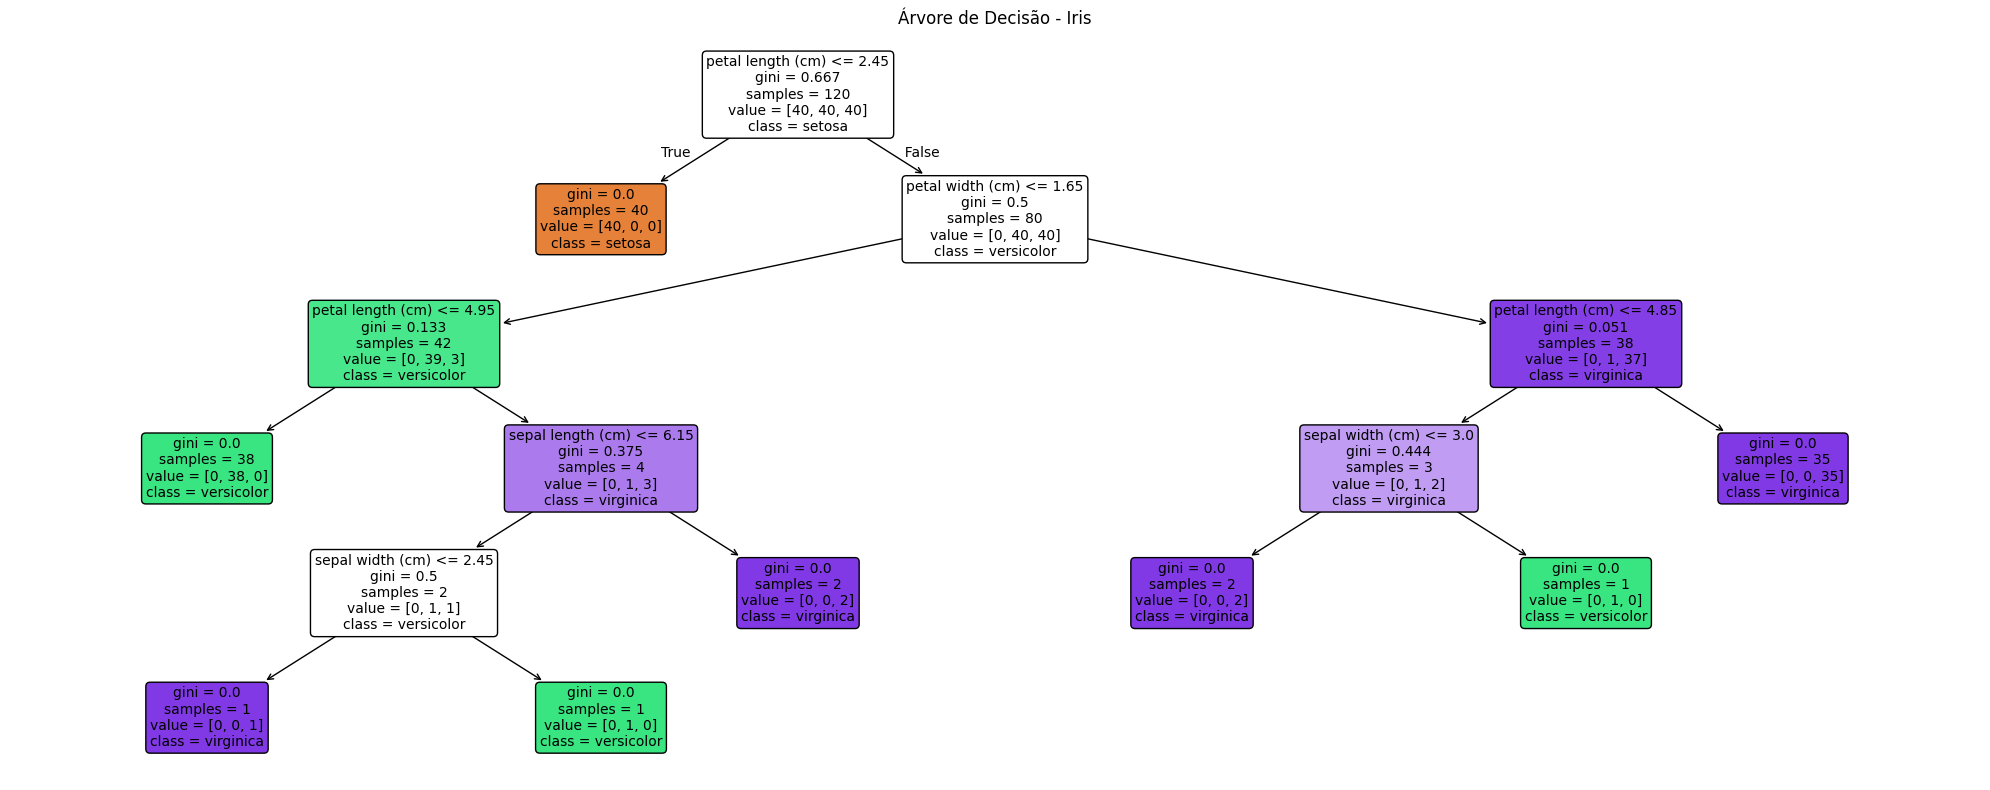

Atributo na raiz: petal length (cm)
Profundidade da árvore: 5


In [22]:
plt.figure(figsize=(20, 8))
plot_tree(
    clf,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    fontsize=10,
)
plt.title("Árvore de Decisão - Iris")
plt.tight_layout()
plt.show()

print(f"Atributo na raiz: {iris.feature_names[clf.tree_.feature[0]]}")
print(f"Profundidade da árvore: {clf.get_depth()}")


# Questão 4

Treine dez árvores com:

- max_depth = 1
- max_depth = 2
- max_depth = 3
...
- max_depth = 9
- max_depth = None

Registre em uma tabela para cada árvore:

- acurácia no treino
- acurácia no teste
- profundidade da árvore
- número de folhas

**Solução**:

In [23]:
resultados = []

for max_depth in list(range(1, 10)) + [None]:
    modelo = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    modelo.fit(X_treino, y_treino)

    resultados.append({
        "max_depth": str(max_depth) if max_depth is not None else "None",
        "acc_treino": accuracy_score(y_treino, modelo.predict(X_treino)),
        "acc_teste": accuracy_score(y_teste, modelo.predict(X_teste)),
        "profundidade": modelo.get_depth(),
        "n_folhas": modelo.get_n_leaves(),
    })

df_resultados = pd.DataFrame(resultados)
df_resultados.columns = ["max_depth", "Acurácia Treino", "Acurácia Teste", "Profundidade", "Nº de Folhas"]
df_resultados


,max_depth,Acurácia Treino,Acurácia Teste,Profundidade,Nº de Folhas
0,1,0.666667,0.666667,1,2
1,2,0.966667,0.933333,2,3
2,3,0.983333,0.966667,3,5
3,4,0.991667,0.933333,4,7
4,5,1.000000,0.933333,5,8
5,6,1.000000,0.933333,5,8
6,7,1.000000,0.933333,5,8
7,8,1.000000,0.933333,5,8
8,9,1.000000,0.933333,5,8
9,None,1.000000,0.933333,5,8


**Em qual profundidade começa o overfitting?**

A partir de max_depth = 5 a acurácia no treino atinge 100%, enquanto a acurácia no teste para de crescer ou começa a oscilar. Isso indica que o modelo começa a memorizar os dados de treino em vez de generalizar, caracterizando overfitting.

**Por que a árvore consegue 100% no treino quando max_depth=None?**

Quando max_depth=None, o algoritmo expande a árvore sem restrição até que todas as folhas sejam puras ou não existam mais divisões possíveis. Com folhas puras, cada amostra de treino é classificada corretamente, resultando em 100% de acurácia no treino. O custo é uma árvore muito profunda e complexa, que tende a ter desempenho inferior no conjunto de teste por ter se ajustado demais aos dados de treino.


# Questão 5

Treine dois modelos:

- criterion = "gini"
- criterion = "entropy"

Compare:

- profundidade da árvore
- acurácia

**Solução**:

In [24]:
comparacao = []

for criterion in ["gini", "entropy"]:
    modelo = DecisionTreeClassifier(criterion=criterion, random_state=42)
    modelo.fit(X_treino, y_treino)

    comparacao.append({
        "criterion": criterion,
        "Acurácia Treino": accuracy_score(y_treino, modelo.predict(X_treino)),
        "Acurácia Teste": accuracy_score(y_teste, modelo.predict(X_teste)),
        "Profundidade": modelo.get_depth(),
        "Nº de Folhas": modelo.get_n_leaves(),
    })

df_comparacao = pd.DataFrame(comparacao)
df_comparacao


,criterion,Acurácia Treino,Acurácia Teste,Profundidade,Nº de Folhas
0,gini,1.0,0.933333,5,8
1,entropy,1.0,0.933333,5,8


# Questão 6

Escolha um hiperparâmetro e investigue seu impacto.

Sugestões:

- max_depth
- min_samples_split
- min_samples_leaf
- criterion

Mostre resultados e interprete.
- melhor modelo encontrado
- acurácia
- parâmetros

**Solução**:

In [26]:
# min_samples_leaf
# Controla o número mínimo de amostras necessárias em uma folha, evitando que a árvore crie folhas com poucos exemplos (reduz overfitting).

valores = [1, 2, 3, 5, 7, 10, 15, 20]
resultados_q6 = []

for v in valores:
    modelo = DecisionTreeClassifier(min_samples_leaf=v, random_state=42)
    modelo.fit(X_treino, y_treino)

    resultados_q6.append({
        "min_samples_leaf": v,
        "Acurácia Treino": accuracy_score(y_treino, modelo.predict(X_treino)),
        "Acurácia Teste": accuracy_score(y_teste, modelo.predict(X_teste)),
        "Profundidade": modelo.get_depth(),
        "Nº de Folhas": modelo.get_n_leaves(),
    })

df_q6 = pd.DataFrame(resultados_q6)

# Melhor modelo (maior acurácia no teste)
melhor = df_q6.loc[df_q6["Acurácia Teste"].idxmax()]

print("Resultados por min_samples_leaf")
print(df_q6.to_string(index=False))
print(f"\nMelhor modelo:")
print(melhor.to_string())


Resultados por min_samples_leaf
 min_samples_leaf  Acurácia Treino  Acurácia Teste  Profundidade  Nº de Folhas
                1         1.000000        0.933333             5             8
                2         0.983333        0.933333             4             6
                3         0.983333        0.966667             3             5
                5         0.966667        0.933333             3             5
                7         0.966667        0.933333             3             5
               10         0.966667        0.933333             3             5
               15         0.966667        0.933333             3             5
               20         0.966667        0.933333             3             4

Melhor modelo:
min_samples_leaf    3.000000
Acurácia Treino     0.983333
Acurácia Teste      0.966667
Profundidade        3.000000
Nº de Folhas        5.000000


**Interpretação:**

O hiperparâmetro investigado foi min_samples_leaf, que define o número mínimo de amostras que uma folha da árvore deve conter.

- Com min_samples_leaf=1 (padrão), a árvore pode criar folhas com uma única amostra, levando a overfitting (100% no treino, menor acurácia no teste).
- Ao aumentar o valor, a árvore se torna mais simples (menos profunda, menos folhas), o que melhora a generalização até um certo ponto.
- A partir de valores muito altos (ex.: 15, 20), o modelo começa a underfit, pois fica restrito demais para capturar os padrões dos dados.
- O melhor equilíbrio entre acurácia no treino e no teste é encontrado com valores intermediários
